>>KB
{'!B|!A|C', 'A', 'B|!A'}
>>Alpha
{'C', 'B|A'}
Entailment is True
---------------------------
>>KB
{'X4|X1', 'X2', 'X3|X2', '!X4|!X3|X2', 'X2|X4|X3', 'X1'}
>>Alpha
{'X4|X2|X3', '!X2|X4|X1'}
Entailment is True
Entailment is True
Testing n=3 (Variables: 3, KB Clauses: 7, Alpha Clauses: 1)
  -> Avg PL-Res Time: 0.00021s | Avg DPLL Time: 0.00000s

Testing n=4 (Variables: 4, KB Clauses: 10, Alpha Clauses: 2)
  -> Avg PL-Res Time: 0.00294s | Avg DPLL Time: 0.00000s

Testing n=5 (Variables: 5, KB Clauses: 12, Alpha Clauses: 2)
  -> Avg PL-Res Time: 0.04239s | Avg DPLL Time: 0.00000s

Testing n=6 (Variables: 6, KB Clauses: 15, Alpha Clauses: 3)
  -> Avg PL-Res Time: 0.53271s | Avg DPLL Time: 0.00000s

Testing n=7 (Variables: 7, KB Clauses: 17, Alpha Clauses: 3)
  -> Avg PL-Res Time: 23.41835s | Avg DPLL Time: 0.00005s

✅ Completeness Check Passed: Both algorithms agreed on all outputs.


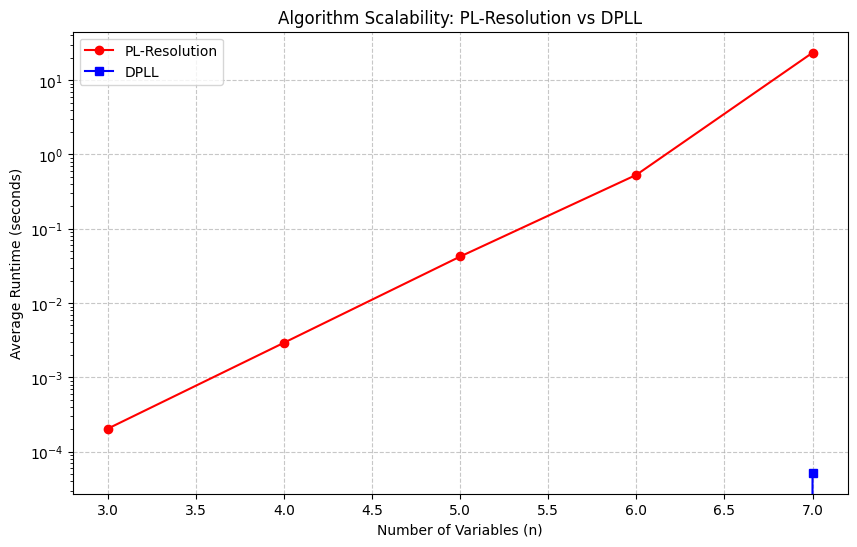

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
# Test your function first with these manually entered KB-alpha pairs
KB1 = {"X2|!X1", "X1"}
Alpha1 = {"X2"}

KB2 = {"B|!A", "A", "!B|!A|C"}
Alpha2 = {"B|A", "C"}

KB3 = {"!Burglar|Alarm", "!Earthquake|Alarm", "!Alarm|JohnCall", "!Alarm|MaryCall"}
Alpha3 = {"!Burglar|JohnCall", "!Burglar|MaryCall"}

# A random KB-alpha pair generator
# Call this function to create bigger problems to evaluate your functions
# n: total number of variables in KB and alpha
# m_kb: the number of disjunctive clauses in the KB
# m_alpha: the number of disjunctive clauses in the query
# p: the probability of having negated literals
def kbq_gen(n=3, m_kb=6, m_alpha=1, p=0.3):
    assignment = np.random.choice([True, False], n)
    kb = set()
    kb_std = set()
    for i in range(m_kb):
        while True:
            lcnt = np.random.randint(1, n)
            vars = np.random.choice(np.arange(n)+1, lcnt, replace=False)
            polarity = np.random.choice(["", "!"], len(vars), p=[1-p, p])
            res = False
            for j in range(lcnt):
                if polarity[j]=="!": res = res or not assignment[vars[j]-1]
                else: res = res or assignment[vars[j]-1]
            if res:
                literals = [polarity[i]+"X"+str(vars[i]) for i in range(len(vars))]
                if "|".join(np.sort(np.array(literals))) not in kb_std:
                    kb.add("|".join(literals))
                    kb_std.add("|".join(np.sort(np.array(literals))))
                    break
    alpha = set()
    alpha_std = set()
    for i in range(m_alpha):
        while True:
            lcnt = np.random.randint(1, n)
            vars = np.random.choice(np.arange(n)+1, lcnt, replace=False)
            polarity = np.random.choice(["", "!"], len(vars), p=[1-p, p])
            literals = [polarity[i]+"X"+str(vars[i]) for i in range(len(vars))]
            if "|".join(np.sort(np.array(literals))) not in alpha_std:
                alpha.add("|".join(literals))
                alpha_std.add("|".join(np.sort(np.array(literals))))
                break
    return kb, alpha

#assistant clause
def negate_literal(l):
    #negates l var
    if l.startswith('!'):
        return l[1:]
    return '!' + l
def parse_clause(c_str):
    #Converts a clause string 'A|!B' into a set of literals {'A', '!B'}.
    return frozenset(c_str.split('|'))

#PL Resolution supporting funcs
def pl_resolve(ci, cj):
    """Returns all possible resolvents from two clauses."""
    resolvents = set()
    for di in ci:
        for dj in cj:
            if di == negate_literal(dj):
                # Resolve on di and dj
                res = set(ci) | set(cj)
                res.remove(di)
                res.remove(dj)
                
                # Check if the resulting clause is a tautology (contains A and !A)
                is_tautology = False
                for lit in res:
                    if negate_literal(lit) in res:
                        is_tautology = True
                        break
                
                if not is_tautology:
                    resolvents.add(frozenset(res))
    return resolvents

def pl_resolution_satisfiable(clauses):
    """Returns True if satisfiable, False if unsatisfiable."""
    new = set()
    while True:
        clauses_list = list(clauses)
        n = len(clauses_list)
        
        for i in range(n):
            for j in range(i + 1, n):
                resolvents = pl_resolve(clauses_list[i], clauses_list[j])
                # If empty clause, KB is unsatisfiable
                if frozenset() in resolvents:
                    return False 
                
                new = new.union(resolvents)
                
        # If no new clauses were added, exhausted resolution without finding contradiction
        if new.issubset(clauses):
            return True 
        
        clauses = clauses.union(new)

# DPLL Implementation

def get_symbols(clauses):
    """Extracts all unique base symbols from the clauses."""
    symbols = set()
    for c in clauses:
        for lit in c:
            symbols.add(lit[1:] if lit.startswith('!') else lit)
    return symbols

def simplify_clauses(clauses, literal):
    """Simplifies the KB given a true literal."""
    new_clauses = set()
    neg_lit = negate_literal(literal)
    for c in clauses:
        if literal in c:
            continue # Clause is satisfied, remove it
        if neg_lit in c:
            # Literal is false, removes it
            new_c = frozenset(l for l in c if l != neg_lit)
            new_clauses.add(new_c)
        else:
            new_clauses.add(c)
    return new_clauses

def dpll(clauses, symbols):
    """Returns True if the clauses are satisfiable, False otherwise."""
    # Base Cases
    if not clauses: return True                # All clauses satisfied
    if frozenset() in clauses: return False    # Empty clause exists -> unsatisfiable

    # Unit Clause Heuristic
    for c in clauses:
        if len(c) == 1:
            literal = next(iter(c))
            sym = literal[1:] if literal.startswith('!') else literal
            symbols_remaining = symbols - {sym}
            return dpll(simplify_clauses(clauses, literal), symbols_remaining)

    # Standard Backtracking (Assign True/False to the next symbol)
    sym = next(iter(symbols))
    symbols_remaining = symbols - {sym}
    
    # Branch on True or False
    return (dpll(simplify_clauses(clauses, sym), symbols_remaining) or 
            dpll(simplify_clauses(clauses, negate_literal(sym)), symbols_remaining))

def master_Entailment_check(KB,alpha,sat_method):
    """
    General handler to check if KB |= alpha using given satisfication mathod
    Returns True if KB entails alpha, False otherwise.
    """
    for alpha_clause in alpha:
        # Convert KB to manageable sets
        kb_clauses = {parse_clause(c) for c in KB}
        
        # Negate the alpha clause and add each literal as a unit clause
        for lit in alpha_clause.split('|'):
            kb_clauses.add(frozenset([negate_literal(lit)]))
            
        # If the solver finds this satisfiable, then KB does NOT entail alpha_clause
        if sat_method(kb_clauses):
            return False
            
    # If all negated alpha clauses lead to unsatisfiability, entailment holds
    return True

# Function to prove entailment using the resolution rule
# Return True if KB entails alpha, False otherwise. 
def PL_resolution_entail(KB, alpha):
    return master_Entailment_check(KB, alpha, pl_resolution_satisfiable)

# Function to prove entailment using the DPLL algorithm
# Return True if KB entails alpha, False otherwise
def DPLL_entail(KB, alpha):
    return master_Entailment_check(KB, alpha, lambda c: dpll(c, get_symbols(c)))

print(">>KB")
print(KB2)
print(">>Alpha")
print(Alpha2)
print("Entailment is", PL_resolution_entail(KB1, Alpha1))

print("---------------------------")

myKB, myAlpha = kbq_gen(4, 6, 2) # try more options, like (10, 20, 2), (3, 5, 1), etc. 
print(">>KB")
print(myKB)
print(">>Alpha")
print(myAlpha)
print("Entailment is", PL_resolution_entail(myKB, myAlpha))
print("Entailment is", DPLL_entail(myKB, myAlpha))

#test functions
def evaluation_suite():
    # Parameters for scaling the test
    # We keep n relatively small because PL-Resolution scales very poorly
    n_values = [3, 4, 5, 6, 7] 
    trials_per_n = 10
    # Storage for plotting
    pl_times = []
    dpll_times = []
    completeness_passed = True

    for n in n_values:
        # Scale the number of clauses proportionally to variables
        m_kb = int(n * 2.5) 
        m_alpha = max(1, n // 2)
        
        pl_time_total = 0
        dpll_time_total = 0
        
        print(f"Testing n={n} (Variables: {n}, KB Clauses: {m_kb}, Alpha Clauses: {m_alpha})")
        
        for trial in range(trials_per_n):
            # Generate a random problem
            KB, alpha = kbq_gen(n=n, m_kb=m_kb, m_alpha=m_alpha, p=0.3)
            
            # --- Measure PL-Resolution ---
            start_time = time.time()
            pl_result = PL_resolution_entail(KB, alpha)
            pl_time_total += (time.time() - start_time)
            
            # --- Measure DPLL ---
            start_time = time.time()
            dpll_result = DPLL_entail(KB, alpha)
            dpll_time_total += (time.time() - start_time)
            
            # --- Check Completeness ---
            # Both algorithms should mathematically reach the exact same conclusion
            if pl_result != dpll_result:
                print(f"  [!] Mismatch on Trial {trial}! PL: {pl_result}, DPLL: {dpll_result}")
                print(f"      KB: {KB}")
                print(f"      Alpha: {alpha}")
                completeness_passed = False
                
        # Calculate averages for this n
        avg_pl_time = pl_time_total / trials_per_n
        avg_dpll_time = dpll_time_total / trials_per_n
        
        pl_times.append(avg_pl_time)
        dpll_times.append(avg_dpll_time)
        
        print(f"  -> Avg PL-Res Time: {avg_pl_time:.5f}s | Avg DPLL Time: {avg_dpll_time:.5f}s\n")

    # --- Final Completeness Report ---
    if completeness_passed:
        print("✅ Completeness Check Passed: Both algorithms agreed on all outputs.")
    else:
        print("❌ Completeness Check Failed: Algorithms disagreed on one or more outputs.")

    # --- Plotting Scalability ---
    plt.figure(figsize=(10, 6))
    plt.plot(n_values, pl_times, label='PL-Resolution', marker='o', color='red')
    plt.plot(n_values, dpll_times, label='DPLL', marker='s', color='blue')
    
    plt.title('Algorithm Scalability: PL-Resolution vs DPLL')
    plt.xlabel('Number of Variables (n)')
    plt.ylabel('Average Runtime (seconds)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Use a logarithmic scale if PL-Resolution shoots up too fast to see DPLL
    plt.yscale('log') 
    
    plt.show()

# Run the evaluation
evaluation_suite()